# Кластеризация типов искажений в запросах «Самокат»

**Задача (discovery):** мы не знаем заранее, какие типы дефектов есть в поисковых
запросах. Ноутбук их обнаруживает и раскладывает запросы по типам.

**Подход.** Типы искажений различаются *структурой текста*, а не смыслом, поэтому
работаем на символьно-лексических признаках (не на семантических эмбеддингах — те
склеили бы по теме). Каталог (`item_name` + категории) служит словарём «правильных»
слов.

**Метод — гибрид:**
1. Кластеризация (HDBSCAN) как инструмент *discovery* — она честно находит структурные
   типы (латиница, слипшиеся, оборванные), у каждого свой чёткий сигнал.
2. Но опечатка↔мусор — это гладкий *континуум* «тяжести искажения» без естественных
   разрывов. Такую шкалу кластеризация искусственно дробит, поэтому её режем **одним
   порогом** по расстоянию до эталона.

**Выход:** `query_types.csv` (запрос → тип + подсказка исправления) и графики.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, distance
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import HDBSCAN
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
DATA_PATH = "../../data.csv"          # относительно typos/discovery/
TYPO_THRESHOLD = 0.34                 # граница опечатка↔мусор по min_dist_catalog
pd.set_option("display.width", 200, "display.max_columns", 25)

**Результат:** подключены библиотеки, задан путь к данным и порог `TYPO_THRESHOLD = 0.34`.

In [2]:
df = pd.read_csv(DATA_PATH)
queries = pd.Series(df["query"].dropna().unique(), name="query")
print(len(queries), "уникальных запросов")
queries.head(10).tolist()

9496 уникальных запросов


['энергетик без сахара',
 'салат из рубца',
 'барилла',
 'краска для волос орех',
 'творог мя',
 'масло детское',
 'холодец э',
 'чипсы эсте',
 'следки мужские',
 'котлеты охлажденное']

**Результат:** загружено **9 496** уникальных запросов — это объекты будущей кластеризации.

## Шаг 0. Словарь-эталон из каталога

Токенизируем названия товаров и все уровни категорий → множество «настоящих» товарных
слов с частотами. Слово считаем *известным*, если оно есть в каталоге **или** его знает
`pymorphy3` (обычное русское слово).

In [3]:
TOKEN_RE = re.compile(r"[а-яёa-z]+", re.IGNORECASE)

def tokenize(text: str) -> list:
    return TOKEN_RE.findall(str(text).lower())

catalog_cols = ["item_name", "category4_name", "category3_name",
                "category2_name", "category1_name"]
catalog_vocab = Counter()
for col in catalog_cols:
    for name in df[col].dropna():
        catalog_vocab.update(tokenize(name))

CATALOG_WORDS = set(catalog_vocab)

def is_known(token: str) -> bool:
    if token in CATALOG_WORDS:
        return True
    if re.fullmatch(r"[а-яё]+", token) and morph.word_is_known(token):
        return True
    return False

print("уникальных слов в каталоге:", len(catalog_vocab))
print("проверка:", is_known("молоко"), is_known("кросчовки"))
catalog_vocab.most_common(8)

уникальных слов в каталоге: 25227
проверка: True False


[('для', 58792),
 ('и', 51268),
 ('г', 39976),
 ('с', 23663),
 ('изделия', 16756),
 ('шт', 12801),
 ('напитки', 11808),
 ('уход', 11071)]

**Результат:** словарь-эталон из **25 227** слов; функция `is_known` отличает настоящее слово от искажённого (`молоко`→True, `кросчовки`→False).

## Шаг 1. Ближайшее слово каталога

Для неизвестного слова ищем ближайшее слово каталога по нормированному расстоянию
Левенштейна (0 = совпало, 1 = совсем непохоже). Малое расстояние → вероятно опечатка;
большое → мусор/иностранное. Кандидатов ограничиваем частыми словами длиной ≥ 3
(чтобы опечатки не «прилипали» к служебным «г», «шт»). Результат кэшируем.

In [4]:
CANDIDATES = [w for w, c in catalog_vocab.items()
              if c >= 3 and len(w) >= 3 and re.fullmatch(r"[а-яё]+", w)]
_nearest_cache = {}

def nearest_catalog(token: str):
    if token in _nearest_cache:
        return _nearest_cache[token]
    match = process.extractOne(
        token, CANDIDATES, scorer=distance.Levenshtein.normalized_distance)
    _nearest_cache[token] = (match[0], match[1])
    return _nearest_cache[token]

print("кандидатов:", len(CANDIDATES))
print("кросчовки →", nearest_catalog("кросчовки"))

кандидатов: 10011
кросчовки → ('кроссовки', 0.1111111111111111)


**Результат:** функция ближайшего эталона: `кросчовки → кроссовки` с расстоянием **0.11** (близко = вероятная опечатка). Это будущий признак `min_dist_catalog`.

## Шаг 2. Структурные признаки на каждый запрос

Считаем интерпретируемые символьно-лексические сигналы. Отдельно выделим **`can_segment`**
— можно ли неизвестный токен разбить на 2+ известных слова (это и есть «слипшиеся»,
напр. `укропбатон` = укроп + батон). Разбиение ищем динамикой (word-break).

In [5]:
CYR = re.compile(r"[а-яё]")
LAT = re.compile(r"[a-z]")
SEG_WORDS = {w for w in CATALOG_WORDS if len(w) >= 3 and re.fullmatch(r"[а-яё]+", w)}

def has_mixed_alphabet(tok: str) -> bool:
    return bool(CYR.search(tok)) and bool(LAT.search(tok))

def has_repeat_run(text: str, n: int = 3) -> bool:
    return re.search(r"(.)\1{" + str(n - 1) + r",}", text) is not None

def can_segment(tok: str, min_len: int = 3) -> bool:
    """Разбивается ли токен на >=2 известных слова (каждое длиной >= min_len)."""
    if len(tok) < 2 * min_len or not re.fullmatch(r"[а-яё]+", tok):
        return False
    n = len(tok)
    reach = [False] * (n + 1); reach[0] = True
    parts = [0] * (n + 1)
    for i in range(n + 1):
        if not reach[i]:
            continue
        for j in range(i + min_len, n + 1):
            if tok[i:j] in SEG_WORDS and not reach[j]:
                reach[j] = True; parts[j] = parts[i] + 1
    return reach[n] and parts[n] >= 2

**Результат:** определены вспомогательные функции-признаки: смешанный алфавит, повтор буквы и `can_segment` (разбивается ли слипшееся слово на 2 известных).

In [6]:
def extract_features(query: str) -> dict:
    q = str(query).lower()
    toks = tokenize(q)
    n_chars = len(q)
    n_tok = len(toks)
    tok_lens = [len(t) for t in toks] or [0]
    letters = [ch for ch in q if ch.isalpha()]
    n_letters = len(letters) or 1
    unknown = [t for t in toks if not is_known(t)]
    dists = [nearest_catalog(t)[1] for t in unknown if re.fullmatch(r"[а-яё]+", t)]
    last_unknown_short = bool(toks) and (not is_known(toks[-1])) and len(toks[-1]) <= 2
    return {
        "query": query,
        "n_chars": n_chars,
        "n_tokens": n_tok,
        "mean_tok_len": float(np.mean(tok_lens)),
        "max_tok_len": max(tok_lens),
        "frac_lat": sum(bool(LAT.match(c)) for c in letters) / n_letters,
        "frac_cyr": sum(bool(CYR.match(c)) for c in letters) / n_letters,
        "frac_digit": sum(ch.isdigit() for ch in q) / n_chars,
        "frac_known": (n_tok - len(unknown)) / n_tok if n_tok else 1.0,
        "min_dist_catalog": min(dists) if dists else 0.0,
        "can_segment": int(any(can_segment(t) for t in unknown)),
        "flag_mixed_alpha": int(any(has_mixed_alphabet(t) for t in toks)),
        "flag_repeat": int(has_repeat_run(q)),
        "flag_abrupt_tail": int(last_unknown_short),
        "flag_all_latin": int(bool(toks) and all(LAT.match(t) for t in toks)),
    }

feat = pd.DataFrame(extract_features(q) for q in queries)
print(feat.shape)
feat.describe().round(2)

(9496, 15)


,n_chars,n_tokens,mean_tok_len,max_tok_len,frac_lat,frac_cyr,frac_digit,frac_known,min_dist_catalog,can_segment,flag_mixed_alpha,flag_repeat,flag_abrupt_tail,flag_all_latin
count,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00,9496.00
mean,11.54,1.85,5.97,7.02,0.09,0.91,0.00,0.74,0.07,0.01,0.00,0.00,0.01,0.06
std,6.02,0.89,1.98,2.24,0.26,0.26,0.03,0.41,0.13,0.10,0.03,0.04,0.09,0.25
min,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,1.00,4.50,5.00,0.00,1.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00
50%,10.00,2.00,6.00,7.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,15.00,2.00,7.00,8.00,0.00,1.00,0.00,1.00,0.12,0.00,0.00,0.00,0.00,0.00
max,49.00,9.00,21.00,21.00,1.00,1.00,1.00,1.00,0.67,1.00,1.00,1.00,1.00,1.00


**Результат:** таблица признаков **9 496 × 15** — каждый запрос превращён в вектор чисел (это координаты точки для кластеризации).

## Шаг 3. Отсев «ок»

Чистый запрос — все токены известны и нет смешанного алфавита. Откладываем такие в
бакет `ок`; кластеризуем только подозрительный остаток.

In [7]:
is_ok = (feat["frac_known"] == 1.0) & (feat["flag_mixed_alpha"] == 0)
ok_df = feat[is_ok].copy()
sus_df = feat[~is_ok].copy()
print(f"ок: {len(ok_df)}   подозрительных: {len(sus_df)}")
sus_df.sample(12, random_state=0)[["query", "frac_known", "min_dist_catalog",
                                   "frac_lat", "can_segment", "flag_abrupt_tail"]]

ок: 6574   подозрительных: 2922


,query,frac_known,min_dist_catalog,frac_lat,can_segment,flag_abrupt_tail
5786,печенье кокосо,0.500000,0.142857,0.000000,0,0
70,мультизлаков,0.000000,0.142857,0.000000,1,0
1554,йогурт без сах,0.666667,0.333333,0.000000,0,0
8184,сменные касеты,0.500000,0.142857,0.000000,0,0
2134,вода минеральная акваминирал,0.666667,0.454545,0.000000,0,0
3464,мвгда,0.000000,0.400000,0.000000,0,0
3832,печенье gérard,0.666667,0.000000,0.384615,0,0
935,безалко,0.000000,0.375000,0.000000,0,0
5830,кикер,0.000000,0.333333,0.000000,0,0
5527,мясо seve,0.500000,0.000000,0.500000,0,0


**Результат:** чистых «ок» — **6 574**, подозрительных — **2 922**. Дальше кластеризуем только эти 2 922.

## Шаг 4. Кластеризация как discovery (HDBSCAN)

Кластеризуем по признакам **без абсолютной длины** (она забивала типы) — важны тип
токенов и расстояние до эталона. Перед этим `StandardScaler` приводит все признаки к
одному масштабу (иначе «большие» числа перевесят). HDBSCAN выбран потому, что число
типов неизвестно, а он сам выделяет бакет «шум» (метка −1).

Что мы увидим: HDBSCAN чётко ловит **структурные** типы (у них ясный да/нет-сигнал —
латиница, слипшиеся, оборванные), но однословные опечатки дробит на десятки кластеров,
различающихся лишь величиной `min_dist_catalog`. Это подсказка: опечатка↔мусор — гладкий
континуум, а не набор кластеров.

In [8]:
FEATURE_COLS = ["n_tokens", "frac_lat", "frac_cyr", "frac_digit", "frac_known",
                "min_dist_catalog", "can_segment", "flag_mixed_alpha",
                "flag_repeat", "flag_abrupt_tail", "flag_all_latin"]

X = StandardScaler().fit_transform(sus_df[FEATURE_COLS])
labels = HDBSCAN(min_cluster_size=40, min_samples=5, copy=True).fit_predict(X)
sus_df["cluster"] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"кластеров: {n_clusters}   шум(-1): {(labels == -1).sum()}")
prof = sus_df.groupby("cluster")[FEATURE_COLS].mean().round(2)
prof["size"] = sus_df["cluster"].value_counts()
prof

кластеров: 25   шум(-1): 65


,n_tokens,frac_lat,frac_cyr,frac_digit,frac_known,min_dist_catalog,can_segment,flag_mixed_alpha,flag_repeat,flag_abrupt_tail,flag_all_latin,size
cluster,,,,,,,,,,,,
-1,2.02,0.12,0.88,0.03,0.29,0.26,0.0,0.11,0.12,0.03,0.09,65
0,2.39,0.05,0.94,0.00,0.53,0.35,0.0,0.00,0.00,1.00,0.00,70
1,1.21,0.00,1.00,0.00,0.09,0.33,1.0,0.00,0.00,0.00,0.00,99
2,1.14,1.00,0.00,0.00,0.06,0.00,0.0,0.00,0.00,0.00,1.00,286
3,3.08,0.03,0.97,0.00,0.66,0.24,0.0,0.00,0.00,0.00,0.00,143
4,2.00,0.48,0.52,0.00,0.50,0.05,0.0,0.00,0.00,0.00,0.00,48
5,1.00,0.00,1.00,0.00,0.00,0.50,0.0,0.00,0.00,0.00,0.00,62
6,1.00,0.00,1.00,0.00,0.00,0.43,0.0,0.00,0.00,0.00,0.00,126
7,1.00,0.00,1.00,0.00,0.00,0.29,0.0,0.00,0.00,0.00,0.00,198


**Результат:** HDBSCAN выделил **25 кластеров** + 65 «шум». В профиле: структурные типы отделились чисто, а хвост однословных кластеров различается только `min_dist_catalog` — это разрезанный на полоски континуум опечаток.

**Читаем профиль:** кластеры с `flag_all_latin=1` — латиница; с `can_segment=1` —
слипшиеся; с `flag_abrupt_tail=1` — оборванные. А длинный «хвост» кластеров с
`n_tokens=1, frac_cyr=1` отличается только `min_dist_catalog` — это и есть разрезанный
на полоски континуум опечаток. Ниже — примеры.

In [9]:
for cid in sorted(sus_df["cluster"].unique()):
    sample = sus_df[sus_df["cluster"] == cid]["query"].head(8).tolist()
    print(f"[{cid:>3}] n={ (sus_df['cluster']==cid).sum():>4}  "
          + " | ".join(map(str, sample)))

[ -1] n=  65  сгушонная малако | картофельмялка | лекарство урсофокус | dантисептик | стрептоцидовая маз | коньяк старейшинаюююю | unleashia sisua butter glow stick | шошоладное переженное
[  0] n=  70  творог мя | фрутоняня нв | булоч ки | куриные крылья дл | мука кк | спаржа са | икра ь | каша дт
[  1] n=  99  мультизлаков | щербетмороженное | безлак | сантри | шоколад белакалорий | фаршмак | укропбатон | комбоблинчики
[  2] n= 286  duluth | grands | pici | arrive | hunters | laroche | crusty | limax


[  3] n= 143  шарики для сти | йошкар олинская тушенка | вода без газаз | триммерная головка для хусварн | йогург без сахара | хлеб без драживой | салëные огурец | соль пищевая пова
[  4] n=  48  лимонад fryst | шампунь mxiti | чипсы proteins | печенья took | mira чипсы | nutrilon гастро | печенье bevelta | с arcane
[  5] n=  62  чайлипто | йоугор | йгу | мрцар | чупасупч | сыйлан | скиилм | буену
[  6] n= 126  эвервеч | лабуба | кисадел | нафтусю | оугоец | жевачуи | рошенконфеты | фоутмотив
[  7] n= 198  ростиб | кокороз | копчн | чароде | гордфуд | онегирт | минарьная | совитал
[  8] n= 247  туал | кутба | капто | пергма | баэ | шароли | айкос | безлаткозы
[  9] n= 134  твороженныйсвр | оргонай | нагнисы | напол | газиров | стоучко | маскулан | перецчер
[ 10] n= 101  шима | нэнер | туалетнаябцмага | мизин | итос | йогку | подгу | кисс
[ 11] n= 178  нашуники | кокт | таор | круасс | лвйм | икрв | нриднев | индидвйт
[ 12] n=  56  кисломи | череизов | донисоимо | мидальо | круасанмс | 

**Результат:** примеры запросов по каждому кластеру — глазами подтверждаем смысл кучек (латиница, слипшиеся, оборванные и полоски опечаток).

## Шаг 5. Гибридная таксономия (структура + порог)

Собираем финальные типы простыми интерпретируемыми правилами:
структурные флаги дают чёткие типы, а континуум опечатка↔мусор режем порогом
`TYPO_THRESHOLD` по расстоянию до эталона.

In [10]:
def assign_type(row) -> str:
    if row["flag_all_latin"]:
        return "латиница"
    if row["flag_mixed_alpha"]:
        return "раскладка/mixed"
    if row["frac_lat"] > 0 and row["frac_cyr"] > 0:
        return "бренд-латиницей"
    if row["can_segment"]:
        return "слипшиеся"
    if row["flag_abrupt_tail"]:
        return "оборванный"
    if row["min_dist_catalog"] < TYPO_THRESHOLD:
        return "опечатка"
    return "мусор/непонятное"

sus_df["type"] = sus_df.apply(assign_type, axis=1)
sus_df["type"].value_counts()

type
опечатка            1849
мусор/непонятное     542
латиница             292
слипшиеся             99
бренд-латиницей       72
оборванный            63
раскладка/mixed        5
Name: count, dtype: int64

**Результат:** **7 типов** на подозрительных: опечатка 1849, мусор 542, латиница 292, слипшиеся 99, бренд-латиницей 72, оборванный 63, раскладка 5.

## Шаг 6. Сборка выхода

Склеиваем бакет `ок` и размеченный остаток. Для типа «опечатка» добавляем подсказку
исправления — заменяем неизвестные слова на ближайшие из каталога. Сохраняем
`query_types.csv`.

In [11]:
ok_df["type"] = "ок"
ok_df["cluster"] = -2   # маркер «не кластеризовали»

def correction_hint(row) -> str:
    if row["type"] != "опечатка":
        return ""
    toks = tokenize(row["query"])
    out = []
    for t in toks:
        if not is_known(t) and re.fullmatch(r"[а-яё]+", t):
            out.append(nearest_catalog(t)[0])
        else:
            out.append(t)
    return " ".join(out)

result = pd.concat([sus_df, ok_df], ignore_index=True)
result["correction_hint"] = result.apply(correction_hint, axis=1)

out_cols = (["query", "type", "correction_hint", "cluster"] + FEATURE_COLS)
result[out_cols].to_csv("query_types.csv", index=False)
print("сохранено:", len(result), "строк →", "query_types.csv")
result["type"].value_counts()

сохранено: 9496 строк → query_types.csv


type
ок                  6574
опечатка            1849
мусор/непонятное     542
латиница             292
слипшиеся             99
бренд-латиницей       72
оборванный            63
раскладка/mixed        5
Name: count, dtype: int64

**Результат:** файл **`query_types.csv`** — все **9 496** запросов с типом и подсказкой исправления для опечаток. Это и есть основной выход ноутбука.

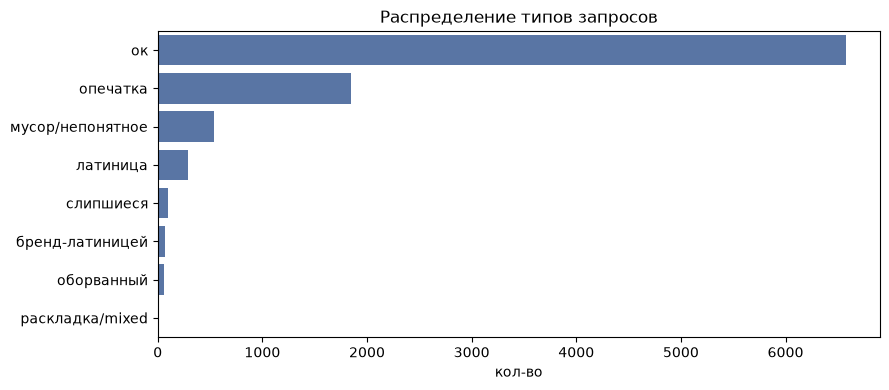

In [12]:
plt.figure(figsize=(9, 4))
order = result["type"].value_counts().index
sns.countplot(data=result, y="type", order=order, color="#4C72B0")
plt.title("Распределение типов запросов"); plt.xlabel("кол-во"); plt.ylabel("")
plt.tight_layout(); plt.savefig("type_distribution.png", dpi=120); plt.show()

**Результат:** график `type_distribution.png` — распределение типов: доминирует «ок», затем «опечатка», остальные типы — заметно реже.

## Шаг 7. 2D-визуализация (UMAP)

Проецируем 11-мерный вектор признаков подозрительных запросов в 2D, чтобы глазами
проверить: отделяются ли типы. UMAP лучше сохраняет локальную структуру, чем PCA;
если не установлен — фолбэк на t-SNE.

/Users/maxos/PythonProjects/LSH/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/maxos/PythonProjects/LSH/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/maxos/PythonProjects/LSH/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/maxos/PythonProjects/LSH/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/maxos/PythonProjects/LSH/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/maxos/PythonProjects/LSH/.venv/lib/python3.12/site-packages/umap/s

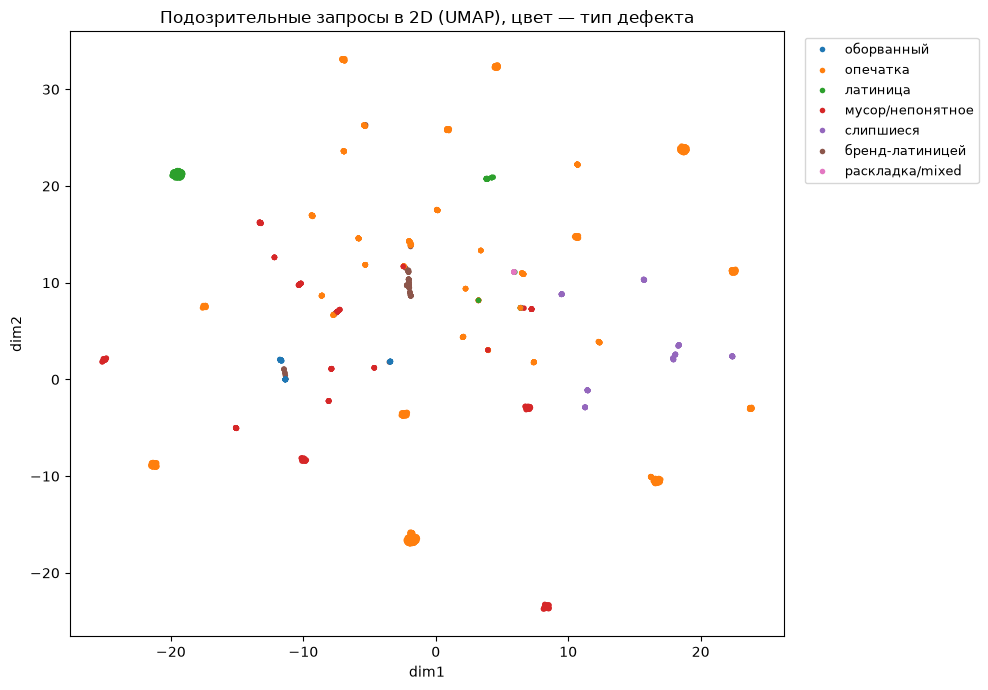

In [13]:
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                        metric="euclidean", random_state=42)
    method = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=30, init="pca", random_state=42)
    method = "t-SNE"

emb = reducer.fit_transform(X)          # X — стандартизованные признаки sus_df
sus_df["dim1"], sus_df["dim2"] = emb[:, 0], emb[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=sus_df, x="dim1", y="dim2", hue="type",
                s=16, linewidth=0, palette="tab10")
plt.title(f"Подозрительные запросы в 2D ({method}), цвет — тип дефекта")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig("clusters_2d.png", dpi=120); plt.show()

**Результат:** `clusters_2d.png` — UMAP-проекция. Латиница собирается в островок, а опечатка/мусор перемешаны — это визуально подтверждает, что они континуум.

### Сравнение: та же проекция через sklearn t-SNE

UMAP выше может рисоваться размазанно. t-SNE на тех же признаках сильнее «раздвигает»
группы — типы (латиница, слипшиеся, оборванный, мусор) видны отдельными островками.
Оставляем оба метода для сравнения.

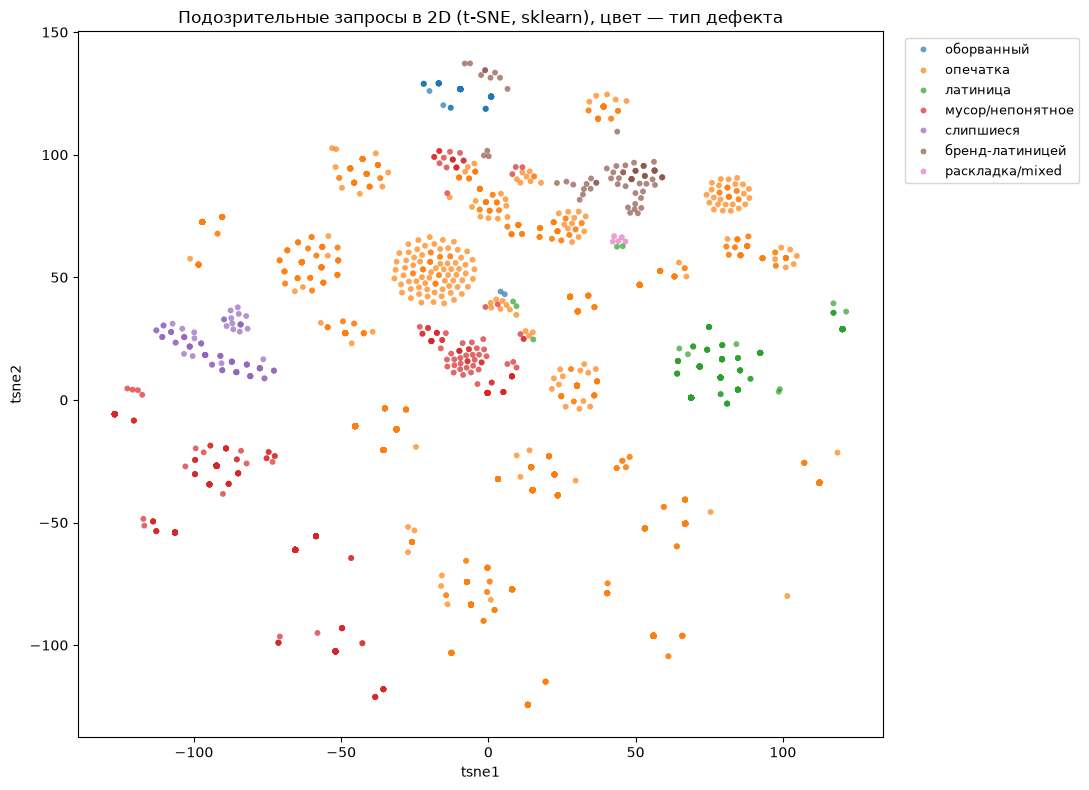

In [14]:
from sklearn.manifold import TSNE

# та же матрица признаков X, но проекция через sklearn t-SNE (для сравнения с UMAP)
emb_tsne = TSNE(n_components=2, perplexity=40, init="pca",
                random_state=42).fit_transform(X)
sus_df["tsne1"], sus_df["tsne2"] = emb_tsne[:, 0], emb_tsne[:, 1]

plt.figure(figsize=(11, 8))
sns.scatterplot(data=sus_df, x="tsne1", y="tsne2", hue="type",
                s=18, linewidth=0, palette="tab10", alpha=0.7)
plt.title("Подозрительные запросы в 2D (t-SNE, sklearn), цвет — тип дефекта")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.savefig("clusters_2d_tsne.png", dpi=120); plt.show()

**Результат:** `clusters_2d_tsne.png` — t-SNE чётче раздвигает типы на островки. Оранжевый («опечатка») разбросан, потому что это широкое правило поверх разных конфигураций признаков (1 слово / фраза с опечаткой / …), а не одна тесная кучка.